# Skriveni stilski rizik u portfeljima minimalne varijance — vizualni sažetak

Naracija cijelog projekta u pet dijelova, ispričana kroz figure.
Svi podaci učitavaju se iz postojećih izlaza — nijedan model se ne procjenjuje ponovno, ne pokreće se nova analiza.

In [13]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

from src.utils import FIGURES_DIR, PROCESSED_DATA_DIR, TABLES_DIR

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.facecolor": "white",
})

# ── Kanonska paleta i prikazni nazivi (usklađeno s notebookovima 01-05) ──
PALETTE = {
    "equal_weight": "#888888",
    "min_var": "#1f77b4",
    "min_var_sector": "#2ca02c",
    "min_var_corr_cluster": "#9467bd",
    "min_var_factor_cluster": "#d62728",
    "factor_neutral_e0": "#ff7f0e",
}
DISPLAY = {
    "equal_weight": "Jednake težine",
    "min_var": "Minimalna varijanca",
    "min_var_sector": "Ograničenje sektora",
    "min_var_corr_cluster": "Ograničenje korel. klastera",
    "min_var_factor_cluster": "Ograničenje fakt. klastera",
    "factor_neutral_e0": "Faktorski neutralan (ε=0)",
}

# ── Reprezentativni prozor ──
REP_WINDOW = "2024-12"
FACTOR_FEATURES = ["beta_mkt", "beta_smb", "beta_hml", "beta_rmw", "beta_cma", "residual_vol"]
STYLE_FACTORS = ["beta_smb", "beta_hml", "beta_rmw", "beta_cma"]

# ── Učitaj sve jednom ──
fe = pd.read_csv(PROCESSED_DATA_DIR / "factor_exposures.csv")
fc = pd.read_csv(PROCESSED_DATA_DIR / "factor_clusters.csv")
wp = pd.read_csv(TABLES_DIR / "weights_panel.csv")
fnw = pd.read_csv(TABLES_DIR / "05_weights_panel_factor_neutral.csv")
attr_full = pd.read_csv(TABLES_DIR / "05_attribution_all_portfolios.csv")
attr_year = pd.read_csv(TABLES_DIR / "05_attribution_per_year.csv")
risk_all = pd.read_csv(TABLES_DIR / "05_risk_summary_all.csv")
returns_ext = pd.read_csv(TABLES_DIR / "05_port_returns_panel_extended.csv",
                          index_col=0, parse_dates=True)

# ── Centroidi klastera (standardizirani) za reprezentativni prozor ──
rep_fe = fe[fe["train_window"] == REP_WINDOW].set_index("ticker")[FACTOR_FEATURES]
rep_fc = fc[fc["train_window"] == REP_WINDOW].set_index("ticker")["factor_cluster"]
standardized = pd.DataFrame(
    StandardScaler().fit_transform(rep_fe),
    index=rep_fe.index, columns=FACTOR_FEATURES,
)
centroids = standardized.groupby(rep_fc).mean()
cluster_sizes = rep_fc.value_counts().sort_index()

# ── Izvedi razumljive nazive klastera iz dominantnih značajki ──
_name_map = {
    (1,): "Neprofitabilni rastući",    # −RMW, −CMA
    (2,): "Duboka vrijednost",         # +HML, −CMA
    (3,): "Špekulativni rast",         # −RMW, −HML
    (4,): "Defenzivne velike dionice", # −SMB, −MKT
    (5,): "Konzervativni rast",        # +CMA, −HML
    (6,): "Profitabilne male dionice", # +RMW, +SMB
    (7,): "Visokovolatilni ciklični",  # +σ_ε, +MKT
}

def _auto_name(row):
    top = row.abs().nlargest(2)
    parts = []
    for feat in top.index:
        short = feat.replace("beta_", "β_").replace("residual_vol", "σ_ε").upper()
        short = short.replace("BETA_", "β_")
        sign = "+" if row[feat] > 0 else "−"
        parts.append(f"{sign}{short}")
    return ", ".join(parts)

CLUSTER_NAMES = {}
for cid, row in centroids.iterrows():
    if (cid,) in _name_map:
        CLUSTER_NAMES[cid] = f"{_name_map[(cid,)]}\n({_auto_name(row)})"
    else:
        CLUSTER_NAMES[cid] = _auto_name(row)

CLUSTER_SHORT = {cid: _name_map.get((cid,), f"C{cid}") for cid in centroids.index}

# ── Pomoćnik: radarski graf ──
def radar_ax(ax, values, labels, color="C0", fill_alpha=0.2, label=None):
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    values_closed = values + [values[0]]
    angles_closed = angles + [angles[0]]
    ax.plot(angles_closed, values_closed, color=color, linewidth=1.6, label=label)
    ax.fill(angles_closed, values_closed, alpha=fill_alpha, color=color)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_yticklabels([])

print("Postavljanje gotovo. Reprezentativni prozor:", REP_WINDOW)
print(f"Veličina univerzuma: {len(rep_fe)} dionica u {len(centroids)} klastera")


Postavljanje gotovo. Reprezentativni prozor: 2024-12
Veličina univerzuma: 884 dionica u 7 klastera


---
## 1. Univerzum i njegova faktorska struktura

*Russell 1000 nije homogen skup — Wardovo klasteriranje na Fama-French faktorskim izloženostima otkriva sedam različitih arhetipova dionica.*

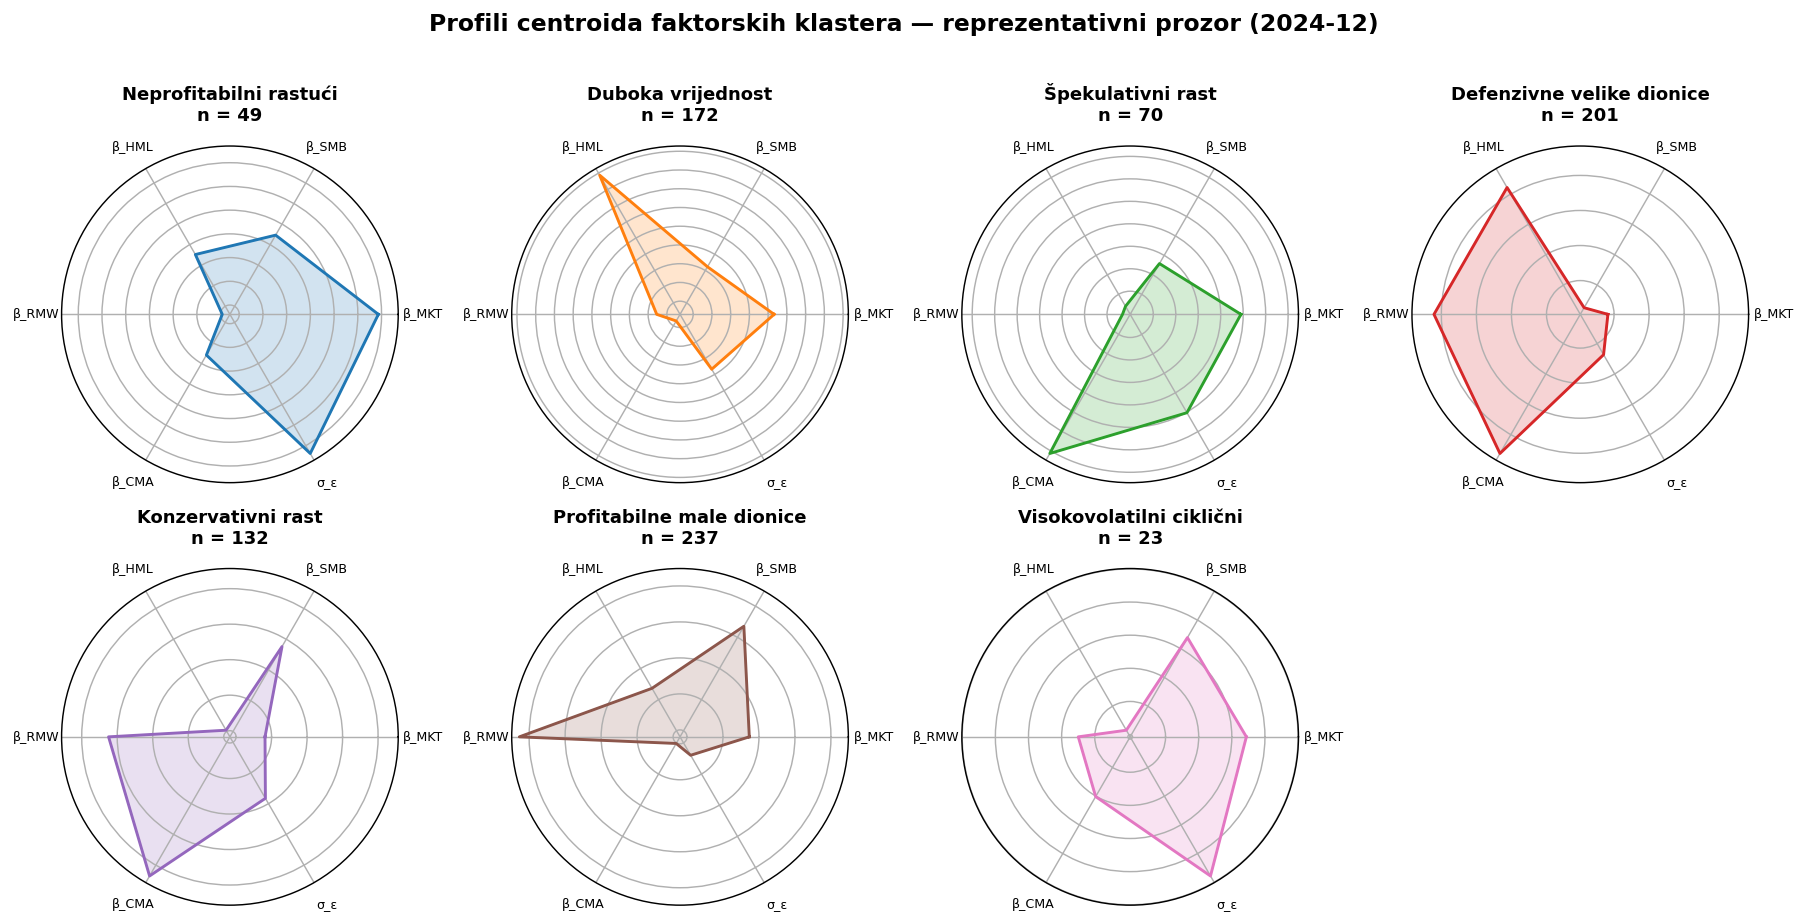

In [14]:
radar_labels = ["β_MKT", "β_SMB", "β_HML", "β_RMW", "β_CMA", "σ_ε"]
n_clusters = len(centroids)
ncols = 4
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7), subplot_kw={"polar": True})
axes_flat = axes.ravel()

for i, (cid, row) in enumerate(centroids.iterrows()):
    ax = axes_flat[i]
    radar_ax(ax, row.tolist(), radar_labels, color=f"C{i}")
    n = cluster_sizes[cid]
    ax.set_title(f"{CLUSTER_SHORT[cid]}\nn = {n}", fontsize=10, fontweight="bold", pad=14)

# Sakrij neiskorišteni podgraf
for j in range(n_clusters, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Profili centroida faktorskih klastera — reprezentativni prozor (2024-12)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


**Zaključak:** Sedam klastera particionira univerzum u koherentne stilske arhetipove — od defenzivnih velikih dionica (niska β_MKT, niska β_SMB) preko profitabilnih malih dionica (visoka β_RMW, visoka β_SMB) do visokovolatilnih cikličnih (visok σ_ε). Ta struktura je leća kroz koju se čita ostatak analize.

---
## 2. Skriveni problem

*Optimizacija minimalne varijance ne samo da smanjuje volatilnost — ona tiho preplavljuje težinom dva specifična faktorska klastera i posljedično poprima velike nagibe profitabilnosti i investiranja.*

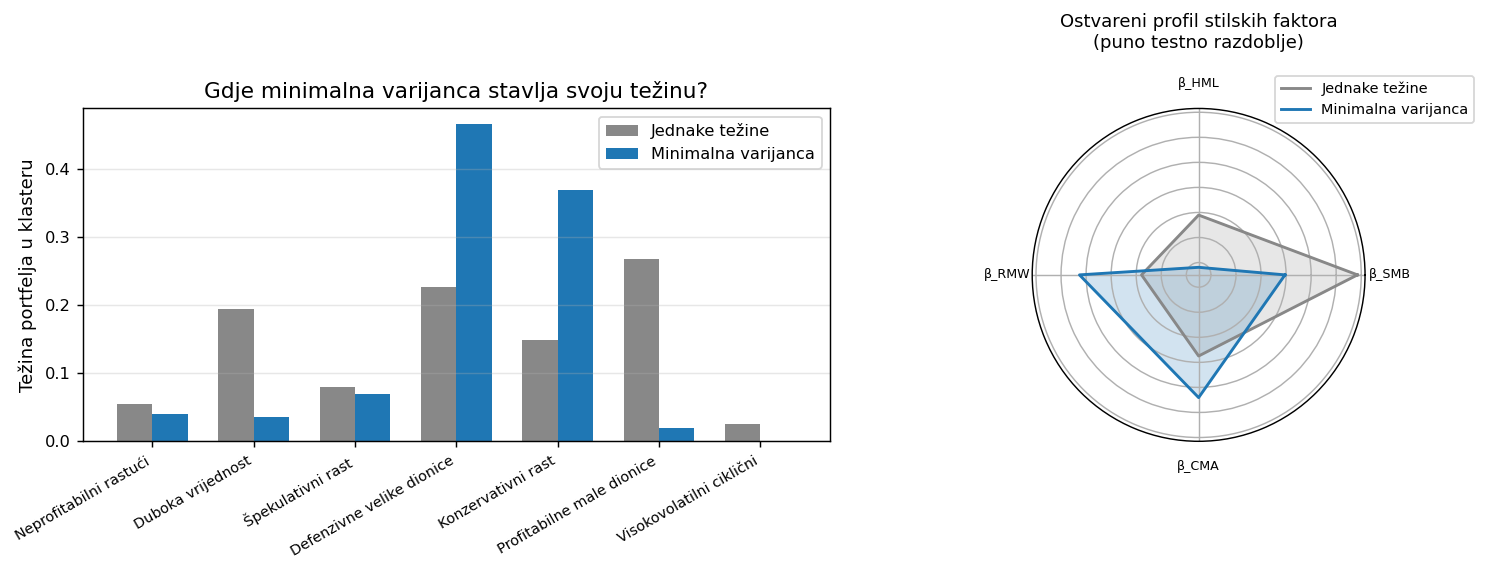

In [15]:
# ── Raspodjela težina po klasterima: min. varijanca naspram jednakih težina ──
wp_rep = wp[wp["train_window"] == REP_WINDOW]
ticker_to_cluster = rep_fc.to_dict()

def cluster_weights(portfolio_weights):
    pw = portfolio_weights.copy()
    pw["cluster"] = pw["ticker"].map(ticker_to_cluster)
    pw = pw.dropna(subset=["cluster"])
    pw["cluster"] = pw["cluster"].astype(int)
    return pw.groupby("cluster")["weight"].sum()

ew_cw = cluster_weights(wp_rep[wp_rep["portfolio"] == "equal_weight"])
mv_cw = cluster_weights(wp_rep[wp_rep["portfolio"] == "min_var"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Lijevo: grupirani stupci
x = np.arange(1, 8)
w = 0.35
xlabels = [CLUSTER_SHORT[c] for c in x]
axes[0].bar(x - w/2, [ew_cw.get(c, 0) for c in x], w, label="Jednake težine", color=PALETTE["equal_weight"])
axes[0].bar(x + w/2, [mv_cw.get(c, 0) for c in x], w, label="Minimalna varijanca", color=PALETTE["min_var"])
axes[0].set_xticks(x)
axes[0].set_xticklabels(xlabels, rotation=30, ha="right", fontsize=8)
axes[0].set_ylabel("Težina portfelja u klasteru")
axes[0].set_title("Gdje minimalna varijanca stavlja svoju težinu?")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# Desno: usporedni radar ostvarenih faktorskih profila
ax_r = fig.add_subplot(1, 2, 2, polar=True)
axes[1].set_visible(False)  # hide the rectangular axes

beta_cols = ["beta_smb", "beta_hml", "beta_rmw", "beta_cma"]
beta_labels = ["β_SMB", "β_HML", "β_RMW", "β_CMA"]

ew_row = attr_full[attr_full["portfolio"] == "equal_weight"][beta_cols].values[0].tolist()
mv_row = attr_full[attr_full["portfolio"] == "min_var"][beta_cols].values[0].tolist()

radar_ax(ax_r, ew_row, beta_labels, color=PALETTE["equal_weight"], label="Jednake težine")
radar_ax(ax_r, mv_row, beta_labels, color=PALETTE["min_var"], label="Minimalna varijanca")
ax_r.set_title("Ostvareni profil stilskih faktora\n(puno testno razdoblje)", fontsize=10, pad=16)
ax_r.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12))

plt.tight_layout()
plt.show()


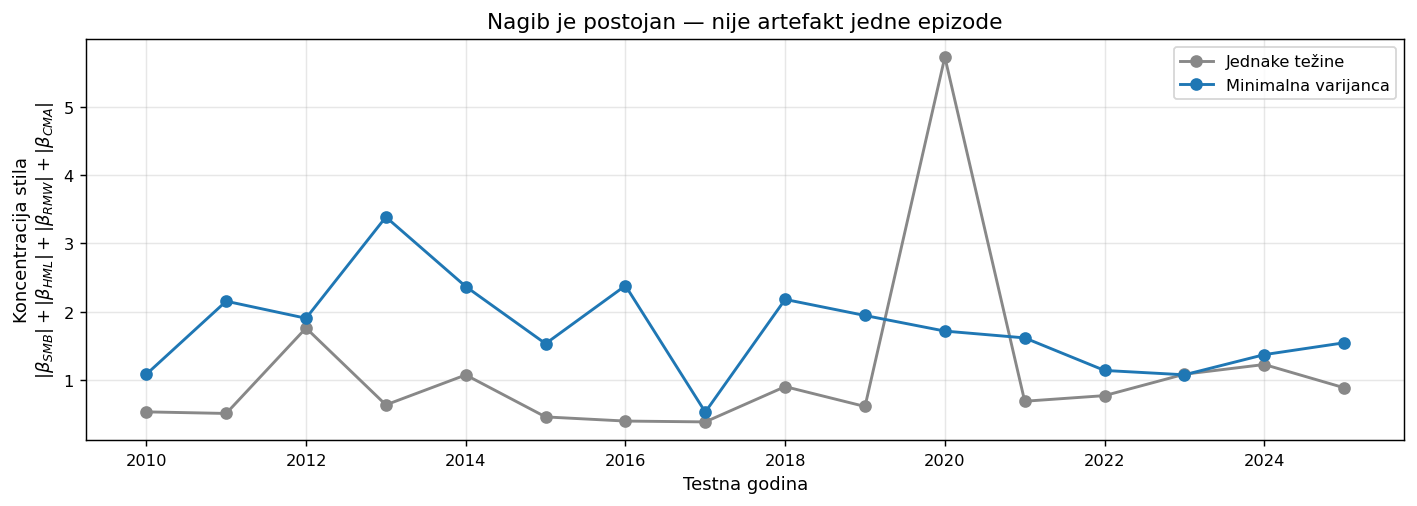

In [16]:
# ── Koncentracija stila po godini: dokaz postojanosti ──
fig, ax = plt.subplots(figsize=(11, 4))
for portfolio in ["equal_weight", "min_var"]:
    sub = attr_year[attr_year["portfolio"] == portfolio]
    ax.plot(sub["test_year"], sub["style_concentration"],
            marker="o", linewidth=1.6, color=PALETTE[portfolio],
            label=DISPLAY[portfolio])
ax.set_xlabel("Testna godina")
ax.set_ylabel("Koncentracija stila\n$|β_{SMB}|+|β_{HML}|+|β_{RMW}|+|β_{CMA}|$")
ax.set_title("Nagib je postojan — nije artefakt jedne epizode")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Zaključak:** Minimalna varijanca koncentrira 84 % svoje težine u samo dva klastera — defenzivne velike dionice i konzervativni rast — i usput poprima β_RMW = +0.33 i β_CMA = +0.34. Nagib je postojan kroz oporavak nakon globalne financijske krize, šok COVID-a i kamatni ciklus 2022. – 2023. To je skriveni stilski rizik: portfelj *izgleda* diversificirano po sektorima, ali je snažno nagnut u prostoru faktora.

---
## 3. Zašto popravak ograničenjem klastera ne uspijeva

*Intuitivan popravak — ograničavanje težine svakog faktorskog klastera na 15 % — prisiljava optimizator da raširi težinu po svih sedam stilskih skupina, ali svaka skupina nosi vlastiti faktorski nagib, a ti se nagibi ne poništavaju.*

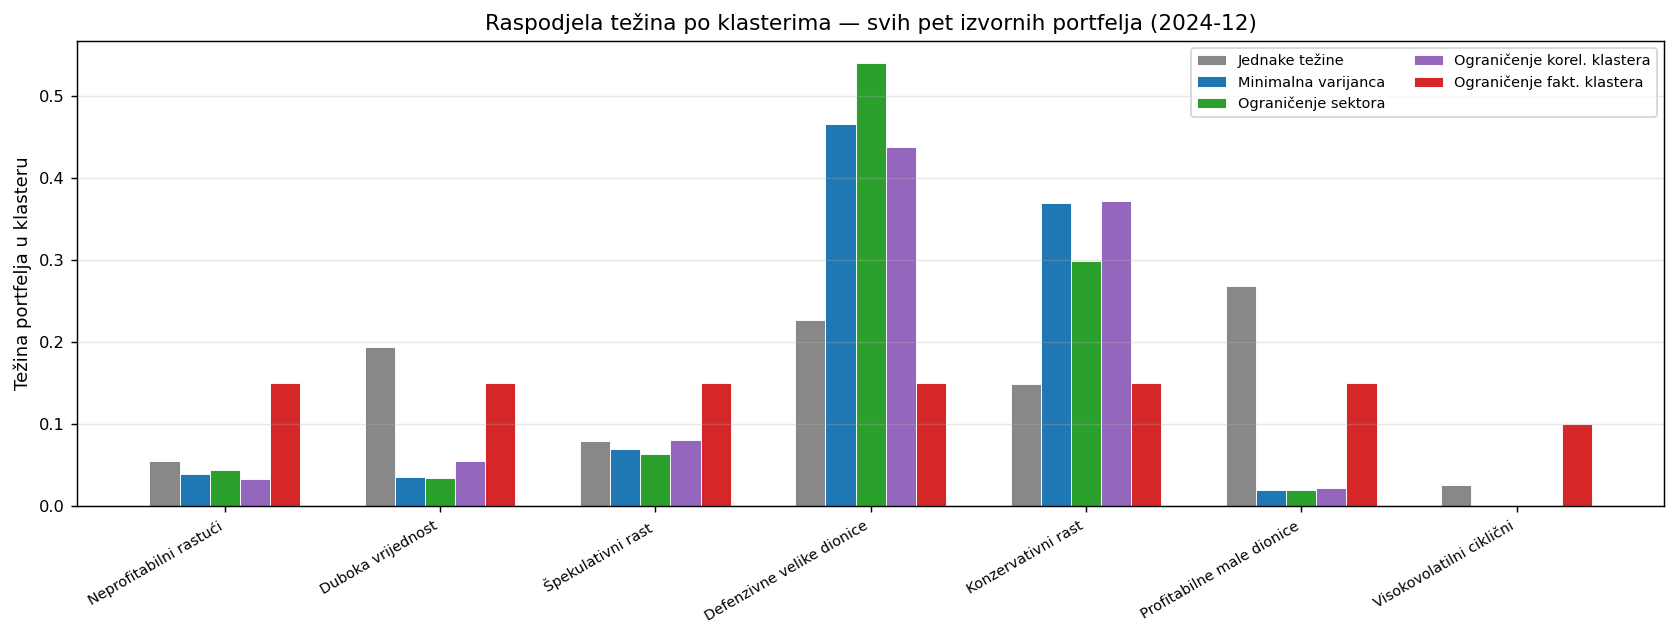

In [17]:
# ── Raspodjela težina po klasterima za svih 5 izvornih portfelja ──
portfolios_5 = ["equal_weight", "min_var", "min_var_sector",
                "min_var_corr_cluster", "min_var_factor_cluster"]
cw_all = {}
for pname in portfolios_5:
    pw = wp_rep[wp_rep["portfolio"] == pname]
    if pw.empty:
        continue
    cw_all[pname] = cluster_weights(pw)

fig, ax = plt.subplots(figsize=(13, 5))
n_p = len(cw_all)
bar_w = 0.14
x = np.arange(1, 8)
for i, pname in enumerate(portfolios_5):
    if pname not in cw_all:
        continue
    vals = [cw_all[pname].get(c, 0) for c in x]
    offset = (i - n_p / 2 + 0.5) * bar_w
    ax.bar(x + offset, vals, bar_w, label=DISPLAY[pname],
           color=PALETTE[pname], edgecolor="white", linewidth=0.5)

xlabels = [CLUSTER_SHORT[c] for c in x]
ax.set_xticks(x)
ax.set_xticklabels(xlabels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Težina portfelja u klasteru")
ax.set_title("Raspodjela težina po klasterima — svih pet izvornih portfelja (2024-12)")
ax.legend(fontsize=8, ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Stupčasti graf prikazuje brojeve, ali paukov graf ispod čini mješavinu arhetipova svakog portfelja odmah čitljivom kao *oblik*. Šiljast radar znači da se portfelj koncentrira u nekoliko arhetipova; okrugao znači da se širi ravnomjerno.

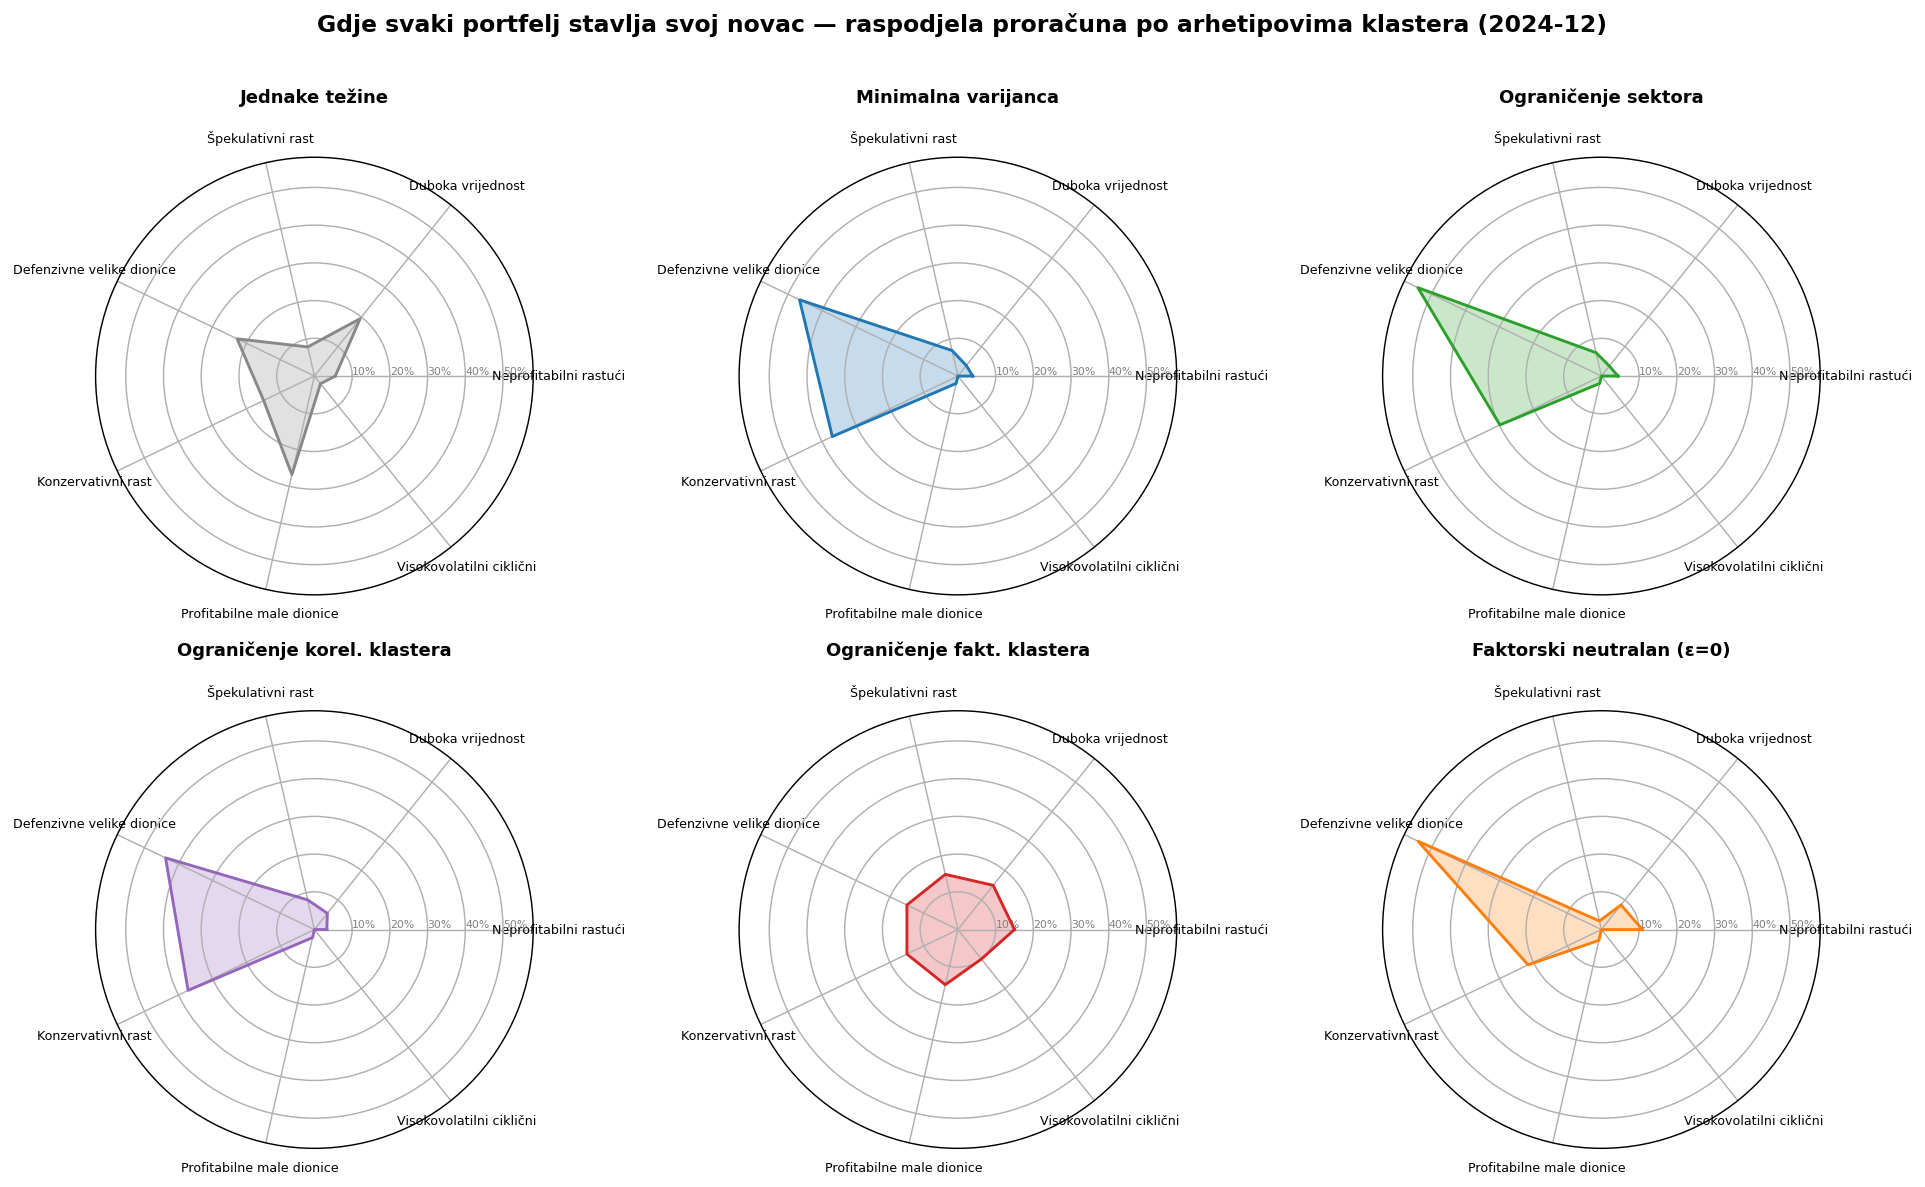

In [18]:
# ── Paukov graf: raspodjela proračuna po klasterima po portfelju ──
# Svaki radar pokazuje kako jedan portfelj raspoređuje težinu po 7 arhetipova.
all_portfolios_6 = ["equal_weight", "min_var", "min_var_sector",
                    "min_var_corr_cluster", "min_var_factor_cluster", "factor_neutral_e0"]

# Izračunaj težine klastera za svih 6 (faktorski neutralan dolazi iz drugog panela težina)
fnw_rep = fnw[(fnw["train_window"] == REP_WINDOW) & (fnw["portfolio"] == "factor_neutral_e0")]
all_weights_rep = pd.concat([wp_rep, fnw_rep], ignore_index=True)

cw_6 = {}
for pname in all_portfolios_6:
    pw = all_weights_rep[all_weights_rep["portfolio"] == pname]
    if pw.empty:
        continue
    cw_6[pname] = cluster_weights(pw)

# Postavljanje radara
cluster_ids = list(range(1, 8))
cluster_radar_labels = [CLUSTER_SHORT[c] for c in cluster_ids]

fig, axes = plt.subplots(2, 3, figsize=(15, 9), subplot_kw={"polar": True})
axes_flat = axes.ravel()

for ax, pname in zip(axes_flat, all_portfolios_6):
    vals = [cw_6[pname].get(c, 0.0) for c in cluster_ids]
    color = PALETTE.get(pname, "#ff7f0e")
    radar_ax(ax, vals, cluster_radar_labels, color=color, fill_alpha=0.25)

    # Označi dominantni klaster(e)
    max_val = max(vals)
    ax.set_title(f"{DISPLAY.get(pname, pname)}", fontsize=10, fontweight="bold", pad=16)
    ax.set_rlabel_position(0)
    ax.set_yticks([0.1, 0.2, 0.3, 0.4, 0.5])
    ax.set_yticklabels(["10%", "20%", "30%", "40%", "50%"], fontsize=6, color="grey")
    ax.set_ylim(0, 0.58)

fig.suptitle("Gdje svaki portfelj stavlja svoj novac — raspodjela proračuna po arhetipovima klastera (2024-12)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


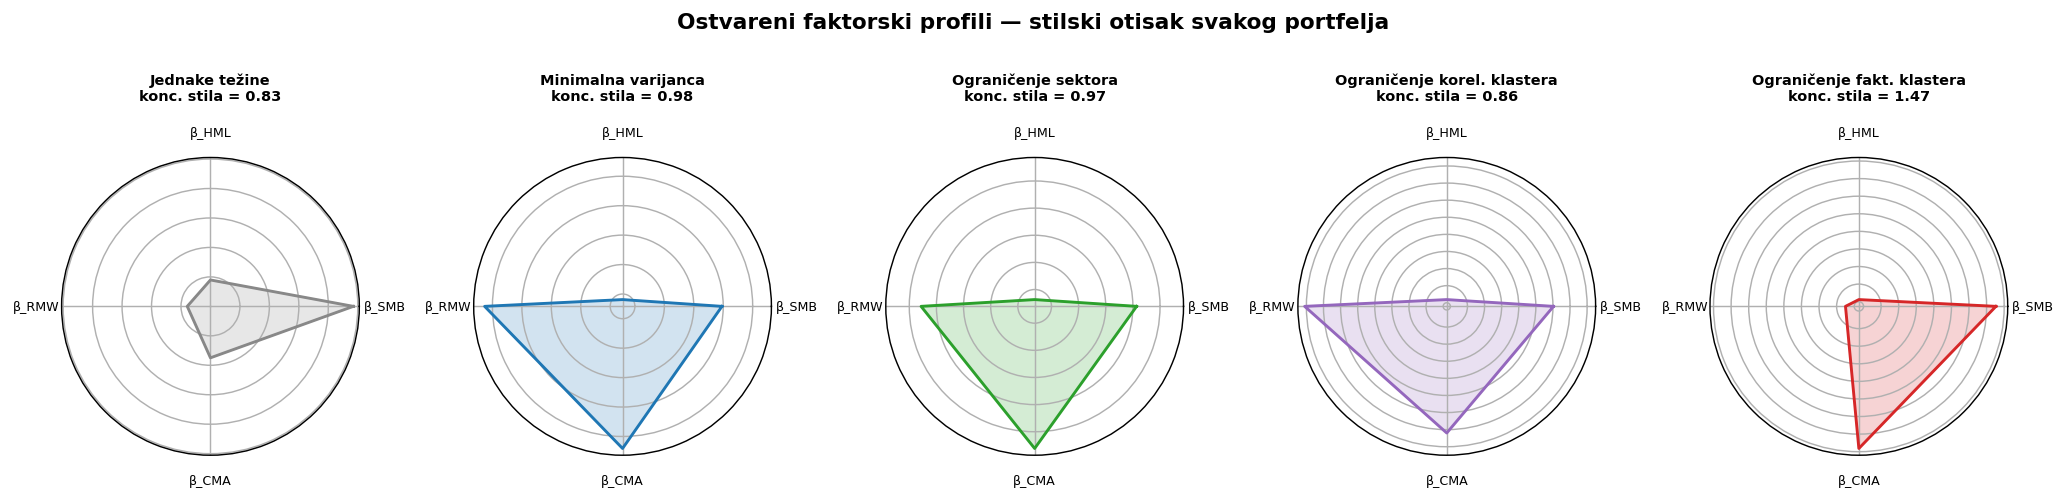

In [19]:
# ── Radar malih višestrukih: ostvareni faktorski profili za 5 portfelja ──
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), subplot_kw={"polar": True})

for ax, pname in zip(axes, portfolios_5):
    row = attr_full[attr_full["portfolio"] == pname]
    if row.empty:
        ax.set_visible(False)
        continue
    vals = row[beta_cols].values[0].tolist()
    radar_ax(ax, vals, beta_labels, color=PALETTE[pname])
    sc = row["style_concentration"].values[0]
    ax.set_title(f"{DISPLAY[pname]}\nkonc. stila = {sc:.2f}",
                 fontsize=8, fontweight="bold", pad=14)

fig.suptitle("Ostvareni faktorski profili — stilski otisak svakog portfelja",
             fontsize=12, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


Ograničenje faktorskih klastera (crveni stupci iznad) uspješno spljošti raspodjelu težina — svaki je klaster ograničen na 15 %. No ravnomjerno širenje težine po sedam stilskih skupina ne neutralizira nijedan pojedini faktor: svaki klaster nosi vlastiti nagib, a težinski prosjek tih nagiba daje β_SMB = +0.55 i β_CMA = +0.58 — *veću* ukupnu koncentraciju stila nego prije, uz 5.8 postotnih bodova veću ostvarenu volatilnost.

**Zaključak:** Ograničavanje grupne težine pogrešna je poluga — ograničava *koliko* težine leži u svakoj stilskoj skupini, ali ne govori ništa o *smjeru* faktorske izloženosti te skupine. Optimizator, prisiljen raširiti težinu, jednostavno je preraspodjeljuje u klastere čiji vlastiti nagibi zbrojeno daju veću ukupnu koncentraciju.

---
## 4. Djelotvoran popravak — izravna faktorska neutralnost

*Umjesto ograničavanja grupnih težina, ograniči ono što je stvarno bitno: faktorske bete portfelja. Dodavanje |w'β_f| ≤ ε izravno u kvadratni program smanjuje koncentraciju stila za 31 % uz nulti trošak volatilnosti.*

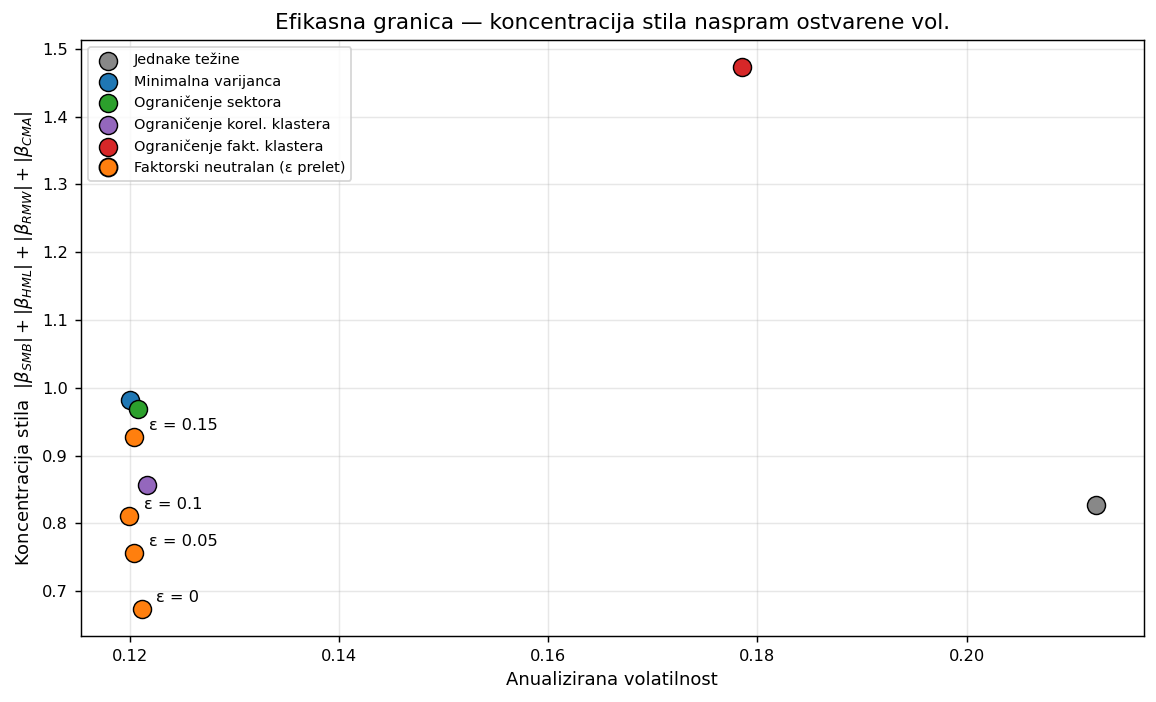

In [20]:
# ── Granica: koncentracija stila naspram ostvarene vol. ──
fig, ax = plt.subplots(figsize=(9, 5.5))

# Osnovni portfelji
for pname in portfolios_5:
    row = risk_all[risk_all["portfolio"] == pname]
    if row.empty:
        continue
    ax.scatter(row["ann_vol"], row["style_concentration"],
               s=100, color=PALETTE[pname], edgecolor="black",
               linewidth=0.8, label=DISPLAY[pname], zorder=5)

# Faktorski neutralna obitelj
fn_portfolios = ["factor_neutral_e0", "factor_neutral_e0.05",
                 "factor_neutral_e0.1", "factor_neutral_e0.15"]
for pname in fn_portfolios:
    row = risk_all[risk_all["portfolio"] == pname]
    if row.empty:
        continue
    eps = pname.replace("factor_neutral_e", "")
    ax.scatter(row["ann_vol"], row["style_concentration"],
               s=100, color="#ff7f0e", marker="o", edgecolor="black",
               linewidth=0.8, zorder=4)
    ax.annotate(f"ε = {eps}", (row["ann_vol"].values[0], row["style_concentration"].values[0]),
                xytext=(8, 4), textcoords="offset points", fontsize=9)

# Sintetički unos u legendu za faktorski neutralan
from matplotlib.lines import Line2D
extra = Line2D([0], [0], marker="o", color="w", label="Faktorski neutralan",
               markerfacecolor="#ff7f0e", markeredgecolor="black", markersize=10)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [extra], labels + ["Faktorski neutralan (ε prelet)"],
          loc="upper left", fontsize=8)

ax.set_xlabel("Anualizirana volatilnost")
ax.set_ylabel("Koncentracija stila  $|β_{SMB}|+|β_{HML}|+|β_{RMW}|+|β_{CMA}|$")
ax.set_title("Efikasna granica — koncentracija stila naspram ostvarene vol.")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


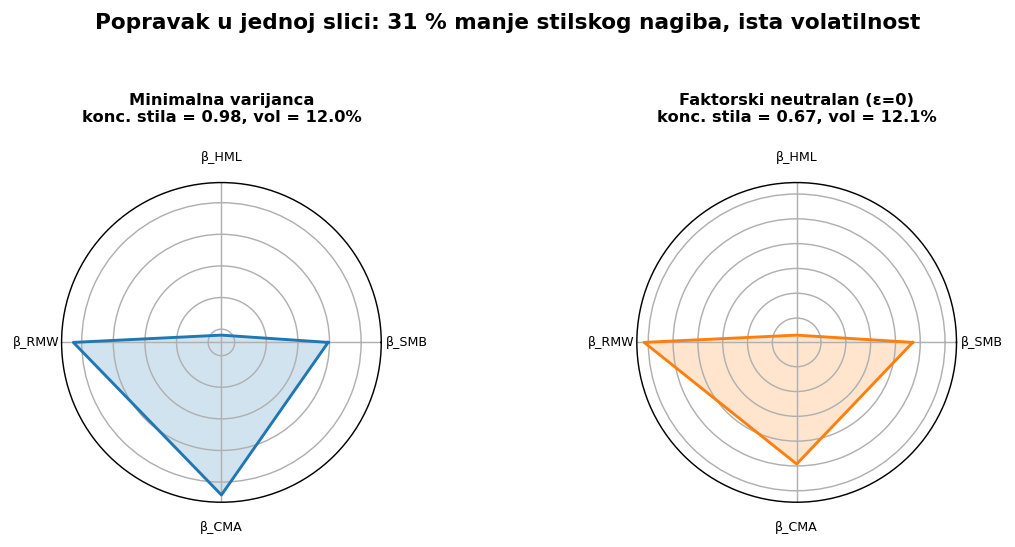

In [21]:
# ── Usporedni radar: min. varijanca naspram faktorski neutralnog ε=0 ──
fig, axes = plt.subplots(1, 2, figsize=(9, 4), subplot_kw={"polar": True})

for ax, pname in zip(axes, ["min_var", "factor_neutral_e0"]):
    row = attr_full[attr_full["portfolio"] == pname]
    vals = row[beta_cols].values[0].tolist()
    radar_ax(ax, vals, beta_labels, color=PALETTE.get(pname, "#ff7f0e"))
    sc = row["style_concentration"].values[0]
    vol = risk_all[risk_all["portfolio"] == pname]["ann_vol"].values[0]
    ax.set_title(f"{DISPLAY.get(pname, pname)}\nkonc. stila = {sc:.2f}, vol = {vol:.1%}",
                 fontsize=9, fontweight="bold", pad=16)

fig.suptitle("Popravak u jednoj slici: 31 % manje stilskog nagiba, ista volatilnost",
             fontsize=12, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()


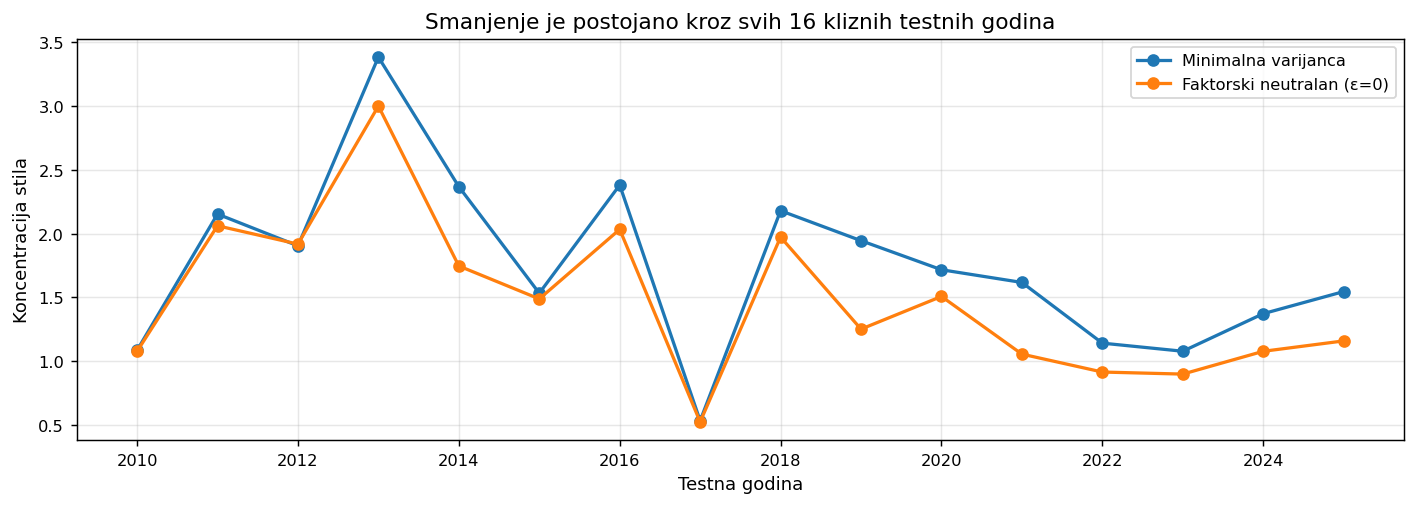

In [22]:
# ── Koncentracija stila po godini: min. varijanca naspram faktorski neutralnog ε=0 ──
fig, ax = plt.subplots(figsize=(11, 4))
for pname in ["min_var", "factor_neutral_e0"]:
    sub = attr_year[attr_year["portfolio"] == pname]
    ax.plot(sub["test_year"], sub["style_concentration"],
            marker="o", linewidth=1.8, color=PALETTE.get(pname, "#ff7f0e"),
            label=DISPLAY.get(pname, pname))
ax.set_xlabel("Testna godina")
ax.set_ylabel("Koncentracija stila")
ax.set_title("Smanjenje je postojano kroz svih 16 kliznih testnih godina")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Zaključak:** Ograničenje faktorske neutralnosti pri ε = 0 smanjuje ostvarenu koncentraciju stila s 0.98 na 0.67 (−31 %) uz anualiziranu volatilnost nepromijenjenu na 12.0 – 12.1 %. Blok-bootstrap 95 % CI na razlici koncentracije stila iznosi [−0.47, −0.09] uz p = 0.002. Klasteriranje nam je reklo *gdje* je problem; izravno faktorsko ograničenje ga ispravlja.

---
## 5. Usporedba portfelja i uspješnost

*Sve na jednom mjestu: potpun profil rizika i prinosa svakog portfelja, od jednakih težina do faktorski neutralnog.*

In [23]:
# ── Stilizirana sažeta tablica ──
focus = ["equal_weight", "min_var", "min_var_sector",
         "min_var_corr_cluster", "min_var_factor_cluster", "factor_neutral_e0"]
summary = risk_all[risk_all["portfolio"].isin(focus)].copy()
summary = summary.set_index("portfolio").reindex(focus)
summary["sharpe"] = summary["ann_return"] / summary["ann_vol"]

cols = {
    "ann_return": "God. prinos",
    "ann_vol": "God. vol.",
    "sharpe": "Sharpe",
    "max_drawdown": "Maks. pad",
    "style_concentration": "Konc. stila",
}
table = summary[list(cols.keys())].rename(columns=cols)
table.index = [DISPLAY.get(p, p) for p in table.index]

def highlight_best_worst(s):
    is_higher_better = s.name in ["God. prinos", "Sharpe"]
    is_lower_better = s.name in ["God. vol.", "Konc. stila"]
    is_least_negative_better = s.name in ["Maks. pad"]

    styles = [""] * len(s)
    vals = s.values.astype(float)

    if is_higher_better:
        best_idx = np.argmax(vals)
        worst_idx = np.argmin(vals)
    elif is_lower_better:
        best_idx = np.argmin(vals)
        worst_idx = np.argmax(vals)
    elif is_least_negative_better:
        best_idx = np.argmax(vals)  # najbliže 0
        worst_idx = np.argmin(vals)  # najnegativnije
    else:
        return styles

    styles[best_idx] = "background-color: #d4edda; font-weight: bold"
    styles[worst_idx] = "background-color: #f8d7da"
    return styles

styled = (
    table.style
    .format({
        "God. prinos": "{:.1%}",
        "God. vol.": "{:.1%}",
        "Sharpe": "{:.2f}",
        "Maks. pad": "{:.1%}",
        "Konc. stila": "{:.2f}",
    })
    .apply(highlight_best_worst, axis=0)
    .set_caption("Sažetak rizika unaprijednim hodom, 2010. – 2025. (16 kliznih prozora)")
)
styled


,God. prinos,God. vol.,Sharpe,Maks. pad,Konc. stila
Jednake težine,19.0%,21.2%,0.90,-27.7%,0.83
Minimalna varijanca,14.0%,12.0%,1.17,-19.4%,0.98
Ograničenje sektora,14.8%,12.1%,1.22,-18.2%,0.97
Ograničenje korel. klastera,13.0%,12.2%,1.07,-28.6%,0.86
Ograničenje fakt. klastera,20.6%,17.9%,1.15,-22.4%,1.47
Faktorski neutralan (ε=0),14.0%,12.1%,1.15,-20.2%,0.67


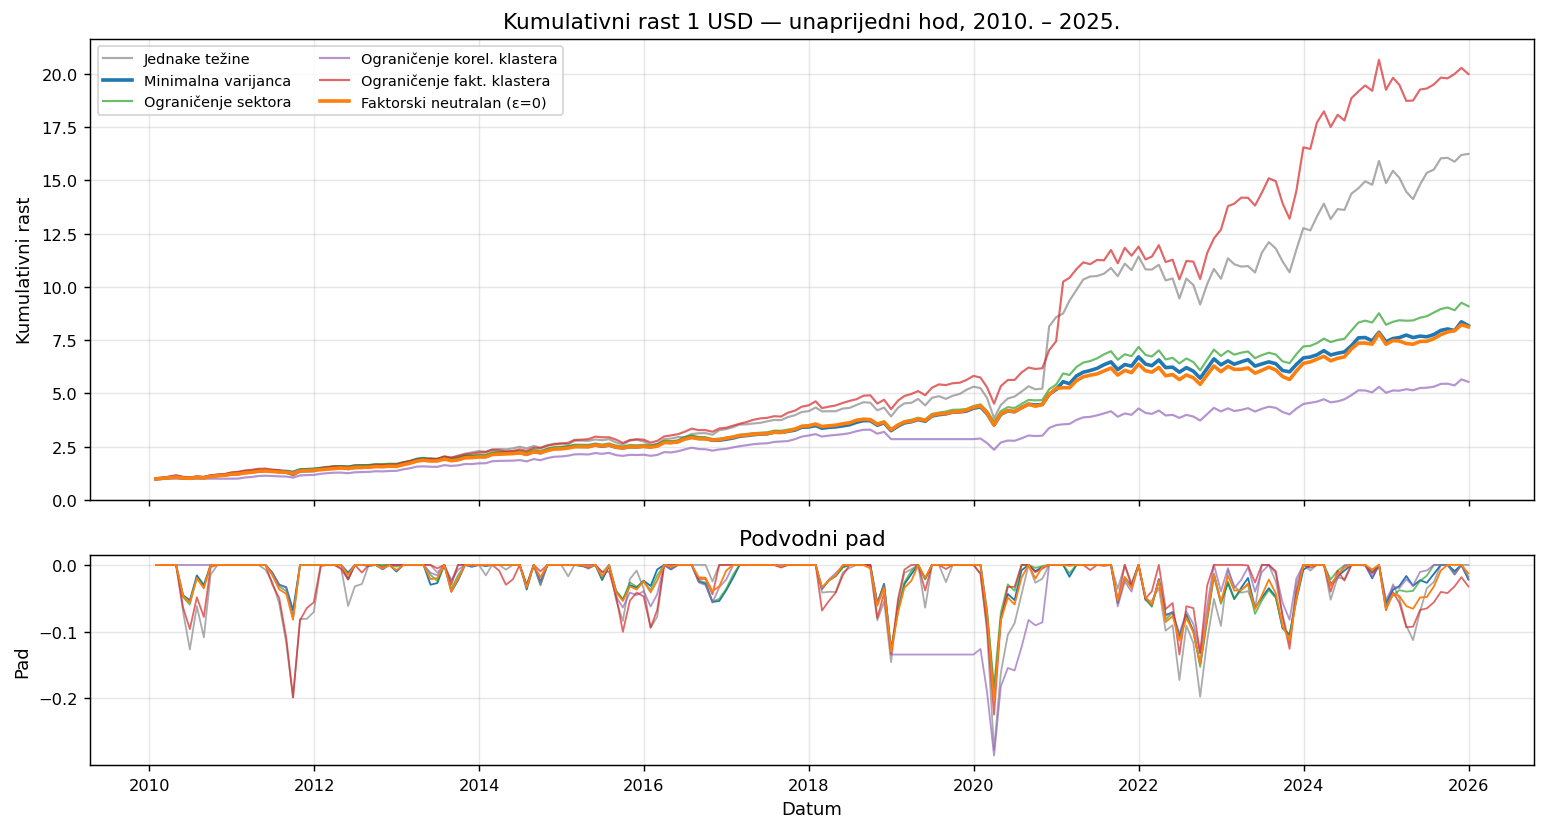

In [24]:
# ── Kumulativni rast 1 USD + podvodni pad ──
port_cols = ["equal_weight", "min_var", "min_var_sector",
             "min_var_corr_cluster", "min_var_factor_cluster", "factor_neutral_e0"]
returns = returns_ext[port_cols].copy()

cumulative = (1.0 + returns.fillna(0.0)).cumprod()
running_max = cumulative.cummax()
drawdown = cumulative / running_max - 1.0

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True,
                          gridspec_kw={"height_ratios": [2.2, 1]})

for pname in port_cols:
    c = PALETTE.get(pname, "#ff7f0e")
    lw = 2.0 if pname in ("min_var", "factor_neutral_e0") else 1.2
    alpha = 1.0 if pname in ("min_var", "factor_neutral_e0") else 0.7
    axes[0].plot(cumulative.index, cumulative[pname],
                 label=DISPLAY.get(pname, pname), color=c,
                 linewidth=lw, alpha=alpha)
    axes[1].plot(drawdown.index, drawdown[pname], color=c,
                 linewidth=1.0, alpha=alpha)

axes[0].set_title("Kumulativni rast 1 USD — unaprijedni hod, 2010. – 2025.")
axes[0].set_ylabel("Kumulativni rast")
axes[0].legend(loc="upper left", fontsize=8, ncol=2)
axes[0].grid(alpha=0.3)

axes[1].set_title("Podvodni pad")
axes[1].set_ylabel("Pad")
axes[1].set_xlabel("Datum")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
### Tri zaključka

1. **Dijagnoza je stvarna.** Portfelji minimalne varijance na Russell 1000 nose skriven, postojan nagib prema Fama-French faktorima profitabilnosti (RMW) i investiranja (CMA) — koncentraciju stila nevidljivu diversifikaciji po sektorima ili korelacijama, ali jasno ocrtanu klasteriranjem u prostoru faktora.

2. **Ograničenja klastera pogrešan su popravak.** Ograničavanje težine po faktorskom klasteru prisiljava optimizator da se raširi po stilskim skupinama, ali svaki klaster nosi vlastiti faktorski nagib i težinski prosjek tih nagiba ne mora se poništiti. Rezultat je *veća* ukupna koncentracija stila uz *veću* ostvarenu volatilnost.

3. **Izravna faktorska neutralnost pravi je popravak.** Dodavanje linearnih ograničenja |w'β_f| ≤ ε u kvadratni program smanjuje ostvarenu koncentraciju stila za 31 % pri ε = 0 bez vidljivog troška u ostvarenoj volatilnosti (p = 0.002 za razliku stila; CI razlike vol. obuhvaća nulu). Aparatura klasteriranja govori nam *što* je problem; nejednakost po faktoru djeluje izravno na njega.